# ARIMA 血糖预测模型 (AutoRegressive Integrated Moving Average)

本 Notebook 实现了一个基于 ARIMA 算法的血糖预测模型。与 KNN 不同，ARIMA 是一种经典的时间序列预测方法，它利用数据自身的滞后值（AR）和滞后预测误差（MA）来预测未来值。

## **主要流程**

1.  **数据加载**:
    *   读取预处理后的训练集 (`Train.csv`) 和测试集 (`Test.csv`)。

2.  **参数分析**:
    *   使用 ADF 检验 (Augmented Dickey-Fuller test) 检查数据的平稳性。
    *   绘制 ACF (自相关函数) 和 PACF (偏自相关函数) 图，辅助确定 ARIMA 的 `(p, d, q)` 参数。

3.  **滚动预测 (Rolling Forecast)**:
    *   由于血糖数据具有很强的个体差异和时变性，我们采用滚动预测策略。
    *   对于测试集中的每一个时间点，利用其之前的历史数据（包括训练集和测试集中已观测到的部分）来拟合模型或更新状态，预测未来的血糖值。

4.  **模型评估**:
    *   **统计指标**: 计算 MAE, RMSE, MAPE, RMSPE。
    *   **临床评估**: 使用 Clarke Error Grid Analysis (克拉克误差网格分析)。
    *   **可视化**: 绘制预测曲线与真实值的对比图。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# 忽略 ARIMA 可能产生的收敛警告
warnings.filterwarnings("ignore")

# Set scientific plotting style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [3]:
# 加载训练集和测试集
train_path = '../../DataSplit/TrainTest/Train.csv'
test_path = '../../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print("训练集形状:", df_train.shape)
print("测试集形状:", df_test.shape)
df_train.head()

训练集形状: (97814, 5)
测试集形状: (11808, 5)


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


正在分析受试者 3 的数据平稳性...
ADF Statistic: -2.2127
p-value: 0.2017
Critical Values:
	1%: -3.4439
	5%: -2.8675
	10%: -2.5700
结论: p-value >= 0.05，不能拒绝原假设，数据可能不平稳，建议进行差分。

一阶差分后 p-value: 0.0000
结论: 一阶差分后平稳 (d=1)。


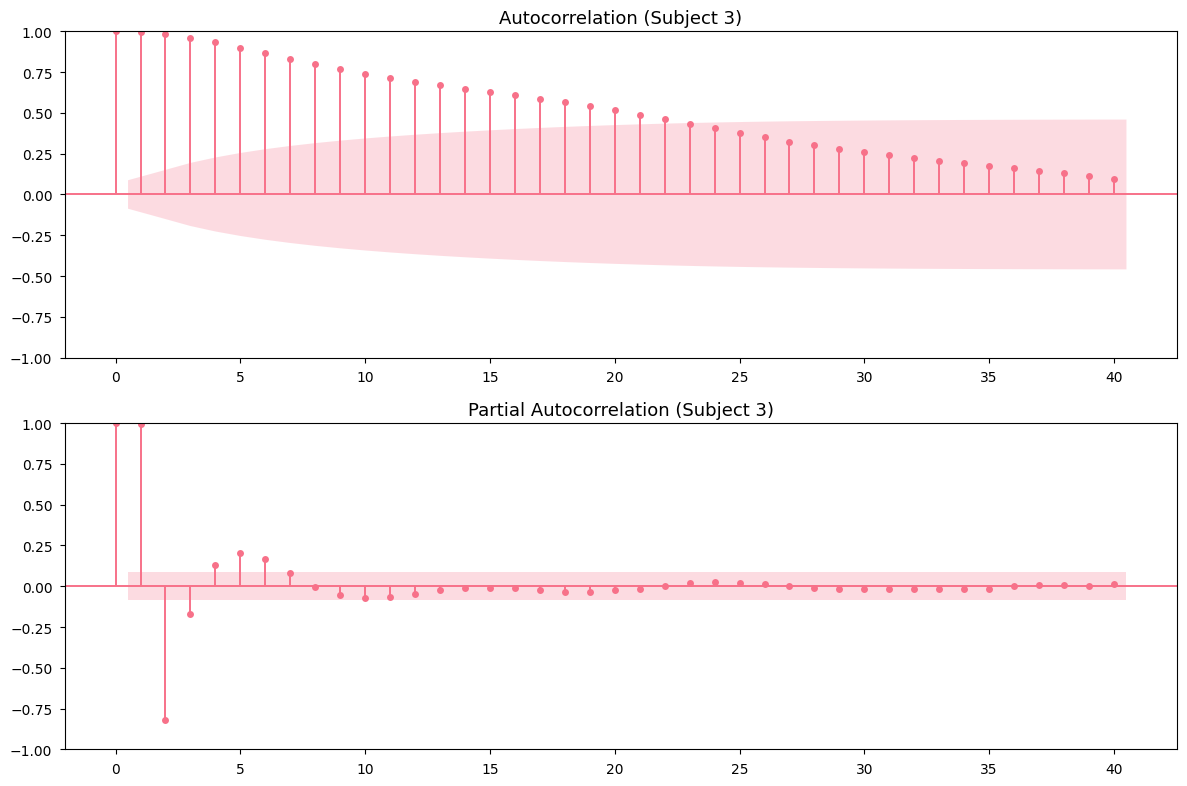


根据 ACF/PACF 图，我们可以初步估计 p 和 q 的值。
通常 ARIMA(p,d,q) 参数选择是一个迭代过程。
为了演示，我们将使用一组经验参数，例如 (5, 1, 0) 或 (2, 1, 1)。


In [4]:
# --- 时间序列平稳性分析 ---

# 随机选取一个受试者的数据进行分析
sample_id = df_train['id'].unique()[0]
sample_data = df_train[df_train['id'] == sample_id]['gl'].values

print(f"正在分析受试者 {sample_id} 的数据平稳性...")

# 1. ADF 检验 (Augmented Dickey-Fuller Test)
# H0: 序列是非平稳的 (存在单位根)
# H1: 序列是平稳的
result = adfuller(sample_data)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] < 0.05:
    print("结论: p-value < 0.05，拒绝原假设，数据是平稳的 (d=0)。")
    d_param = 0
else:
    print("结论: p-value >= 0.05，不能拒绝原假设，数据可能不平稳，建议进行差分。")
    # 尝试一阶差分
    diff_data = np.diff(sample_data)
    result_diff = adfuller(diff_data)
    print(f'\n一阶差分后 p-value: {result_diff[1]:.4f}')
    if result_diff[1] < 0.05:
        print("结论: 一阶差分后平稳 (d=1)。")
        d_param = 1
    else:
        d_param = 1 # 默认至少一阶

# 2. 绘制 ACF 和 PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(sample_data, ax=ax1, lags=40, title=f'Autocorrelation (Subject {sample_id})')
plot_pacf(sample_data, ax=ax2, lags=40, title=f'Partial Autocorrelation (Subject {sample_id})')
plt.tight_layout()
plt.show()

print(f"\n根据 ACF/PACF 图，我们可以初步估计 p 和 q 的值。")
print("通常 ARIMA(p,d,q) 参数选择是一个迭代过程。")
print("为了演示，我们将使用一组经验参数，例如 (5, 1, 0) 或 (2, 1, 1)。")

In [5]:
def arima_rolling_forecast(history, test, order, horizon=1):
    """
    执行 ARIMA 滚动预测
    
    参数:
    history: 初始训练数据 (list 或 array)
    test: 测试集数据 (list 或 array)
    order: ARIMA 参数 (p, d, q)
    horizon: 预测步长 (默认为 1)
    
    返回:
    predictions: 预测值列表
    """
    history = [x for x in history]
    predictions = []
    
    # 限制历史数据长度以加快计算速度 (可选)
    # 如果历史数据太长，ARIMA 拟合会很慢。
    # 这里我们保留最近的 N 个点作为滑动窗口历史
    MAX_HISTORY = 200 
    
    print(f"  开始滚动预测 (Total steps: {len(test)}, Horizon: {horizon})...")
    
    # 滚动预测循环
    # 对于测试集中的每一个点 t (作为预测目标)
    # 我们需要 t - horizon 时刻的历史数据来进行预测
    
    # 简化逻辑：
    # 我们模拟实时过程。
    # 1. 在时刻 t (当前历史末尾)，我们预测 t+horizon 的值。
    # 2. 我们观测到真实值 test[0]，将其加入历史。
    # 3. 重复。
    
    # 注意：为了与 KNN 的 create_dataset 对齐
    # KNN 的 y_test 是 t + horizon - 1 时刻的值
    # 这里我们对 test 序列进行遍历
    
    # 如果 horizon = 1:
    #   Step 0: History=Train. Predict Test[0].
    #   Step 1: History=Train+Test[0]. Predict Test[1].
    
    # 如果 horizon > 1 (例如 3):
    #   Step 0: History=Train. Forecast 3 steps. Pick last one -> Prediction for Test[2].
    #   Step 1: History=Train+Test[0]. Forecast 3 steps. Pick last one -> Prediction for Test[3].
    #   ...
    #   这意味着前 horizon-1 个测试点无法用这种“严格”的滚动方式预测（或者需要更早的历史）。
    #   为了简化，我们从 test 的第 0 个点开始预测 (对应 horizon 步之后的目标)
    #   或者，我们只预测那些能预测的点。
    
    # 这里我们采用标准滚动预测：
    # 对 test 中的每一个点进行单步更新
    
    n_test = len(test)
    
    # 如果 horizon > 1，我们需要调整预测结果的对齐
    # 这里我们简单地做：每次预测未来 horizon 步，取第 horizon 步的值
    
    for t in range(n_test):
        # 使用最近的 MAX_HISTORY 个点
        curr_history = history[-MAX_HISTORY:] if len(history) > MAX_HISTORY else history
        
        try:
            # 拟合模型
            model = ARIMA(curr_history, order=order)
            model_fit = model.fit()
            
            # 预测
            output = model_fit.forecast(steps=horizon)
            yhat = output[-1] # 取第 horizon 步的预测值
            
        except Exception as e:
            print(f"    Error at step {t}: {e}")
            yhat = history[-1] # 发生错误时使用 naive 预测
            
        predictions.append(yhat)
        
        # 更新历史：加入当前的真实观测值
        obs = test[t]
        history.append(obs)
        
        # 简单的进度显示
        if (t+1) % 20 == 0:
            print(f"    Step {t+1}/{n_test} completed.")
            
    return predictions

# 设定 ARIMA 参数 (p, d, q)
# 这里使用经验值，实际应用中应针对每个受试者优化
ARIMA_ORDER = (5, 1, 0) 
PREDICTION_HORIZON = 6  # 预测步长 (1 = 5分钟)

print(f"ARIMA 参数: {ARIMA_ORDER}")
print(f"预测步长: {PREDICTION_HORIZON} ({PREDICTION_HORIZON * 5} 分钟)")

ARIMA 参数: (5, 1, 0)
预测步长: 6 (30 分钟)


In [6]:
# ============ 数据泄漏检查 (Data Leakage Check) ============
print("正在检查潜在的数据泄漏...")

# 1. 检查训练集和测试集是否有时间重叠
leakage_found = False
for subject_id in df_test['id'].unique():
    train_times = df_train[df_train['id'] == subject_id]['time']
    test_times = df_test[df_test['id'] == subject_id]['time']
    
    if train_times.empty or test_times.empty:
        continue
        
    train_max = train_times.max()
    test_min = test_times.min()
    
    if train_max >= test_min:
        print(f"⚠️ 警告: 受试者 {subject_id} 存在时间重叠!")
        print(f"   训练集最后时间: {train_max}")
        print(f"   测试集开始时间: {test_min}")
        leakage_found = True

if not leakage_found:
    print("✅ 检查通过: 所有受试者的训练集时间均早于测试集时间，无重叠。")

# 2. 单步预测验证 (手动执行一步以验证逻辑)
print("\n[单步预测验证]")
subject_id = df_test['id'].unique()[0]
train_subset = df_train[df_train['id'] == subject_id].sort_values('time')
test_subset = df_test[df_test['id'] == subject_id].sort_values('time')

# 准备历史数据
history_data = train_subset['gl'].values.tolist()
# 真实未来数据
future_data = test_subset['gl'].values

# 设定预测步长
h = PREDICTION_HORIZON

print(f"受试者: {subject_id}")
print(f"历史数据长度: {len(history_data)}")
print(f"历史最后一点 (t=0): {history_data[-1]} (Time: {train_subset['time'].iloc[-1]})")
print(f"预测目标: 未来第 {h} 步 (t+{h*5}min)")

# 运行模型预测一步
# 注意：为了验证，我们只使用最后 200 个点来拟合，这与 arima_rolling_forecast 中的逻辑一致
model = ARIMA(history_data[-200:], order=ARIMA_ORDER) 
model_fit = model.fit()
forecast = model_fit.forecast(steps=h)
pred_value = forecast[-1]

# 获取对应的真实值
# 历史最后一点是 Train 的最后一点。
# 未来第 1 步是 Test 的第 0 点。
# 未来第 h 步是 Test 的第 h-1 点。
target_idx = h - 1
if target_idx < len(future_data):
    true_value = future_data[target_idx]
    true_time = test_subset['time'].iloc[target_idx]
    
    print(f"预测值: {pred_value:.2f}")
    print(f"真实值: {true_value:.2f} (Time: {true_time})")
    print(f"误差: {true_value - pred_value:.2f}")
    
    # 检查是否直接等于某个历史值 (Persistence Check)
    if pred_value == history_data[-1]:
        print("提示: 预测值等于历史最后一点 (Persistence/Naive Forecast)。")
    elif pred_value in history_data[-h:]:
        print("提示: 预测值恰好等于近期某个历史值。")
else:
    print("测试集太短，无法验证该步长。")

print("="*60)

正在检查潜在的数据泄漏...
✅ 检查通过: 所有受试者的训练集时间均早于测试集时间，无重叠。

[单步预测验证]
受试者: 3
历史数据长度: 504
历史最后一点 (t=0): 102.84668778280609 (Time: 2012-01-02 17:55:00)
预测目标: 未来第 6 步 (t+30min)
预测值: 101.32
真实值: 101.62 (Time: 2012-01-02 18:25:00)
误差: 0.30


In [7]:
# ============ 主流程：在测试集上执行预测 ============

subject_ids = sorted(df_test['id'].unique())
all_y_true = []
all_y_pred = []
subject_results = [] # 存储每个受试者的详细结果

print(f"开始对 {len(subject_ids)} 个受试者进行 ARIMA 预测...")

for subject_id in subject_ids:
    print(f"\nProcessing Subject {subject_id}...")
    
    # 获取该受试者的训练数据 (历史) 和测试数据 (未来)
    train_series = df_train[df_train['id'] == subject_id].sort_values('time')['gl'].values
    test_series = df_test[df_test['id'] == subject_id].sort_values('time')['gl'].values
    
    # 执行滚动预测
    preds = arima_rolling_forecast(train_series, test_series, ARIMA_ORDER, PREDICTION_HORIZON)
    
    # 对齐真实值和预测值
    # preds[i] 对应 test[i + horizon - 1]
    valid_start_idx = PREDICTION_HORIZON - 1
    if valid_start_idx < len(test_series):
        y_true_subj = test_series[valid_start_idx:]
        y_pred_subj = np.array(preds[:len(y_true_subj)])
        
        all_y_true.extend(y_true_subj)
        all_y_pred.extend(y_pred_subj)
        
        # 计算该受试者的 MAPE
        mask = y_true_subj != 0
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
        
        subject_results.append({
            'id': subject_id,
            'y_true': y_true_subj,
            'y_pred': y_pred_subj,
            'mape': mape_subj,
            'data': df_test[df_test['id'] == subject_id].sort_values('time')
        })
    else:
        print(f"    Warning: Test series too short for horizon {PREDICTION_HORIZON}")

print("\n所有受试者预测完成。")

开始对 164 个受试者进行 ARIMA 预测...

Processing Subject 3...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 5...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 7...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 8...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 10...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 11...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Step 40/72 completed.
    Step 60/72 completed.

Processing Subject 12...
  开始滚动预测 (Total steps: 72, Horizon: 6)...
    Step 20/72 completed.
    Ste

In [8]:
# 计算整体评估指标
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return mae, rmse, mape, rmspe

mae, rmse, mape, rmspe = calculate_metrics(all_y_true, all_y_pred)

print("\n" + "=" * 60)
print(f"📊 ARIMA 预测评估结果 (Horizon={PREDICTION_HORIZON}, {PREDICTION_HORIZON*5} mins)")
print("=" * 60)
print(f"MAE:   {mae:.4f} mg/dL")
print(f"RMSE:  {rmse:.4f} mg/dL")
print(f"MAPE:  {mape:.4f}%")
print(f"RMSPE: {rmspe:.4f}%")
print("=" * 60)


📊 ARIMA 预测评估结果 (Horizon=6, 30 mins)
MAE:   3.2296 mg/dL
RMSE:  4.5839 mg/dL
MAPE:  2.9878%
RMSPE: 4.1056%


可视化 10 个受试者 (Best 5 & Worst 5, 去重后)...


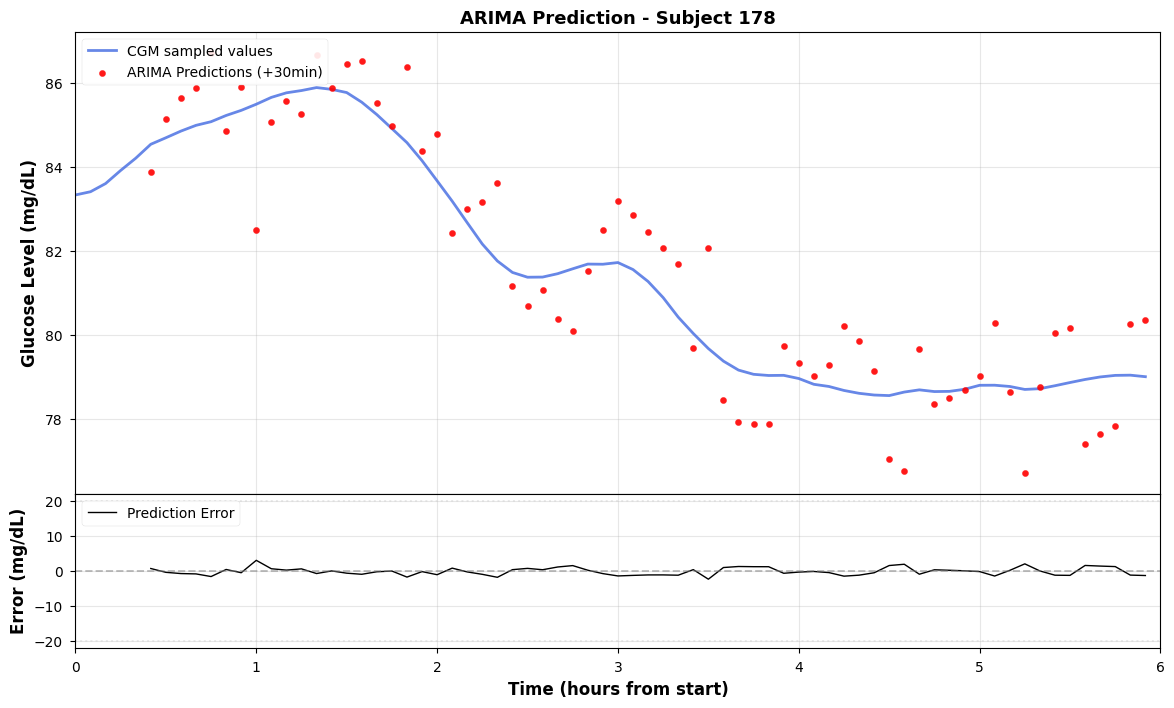

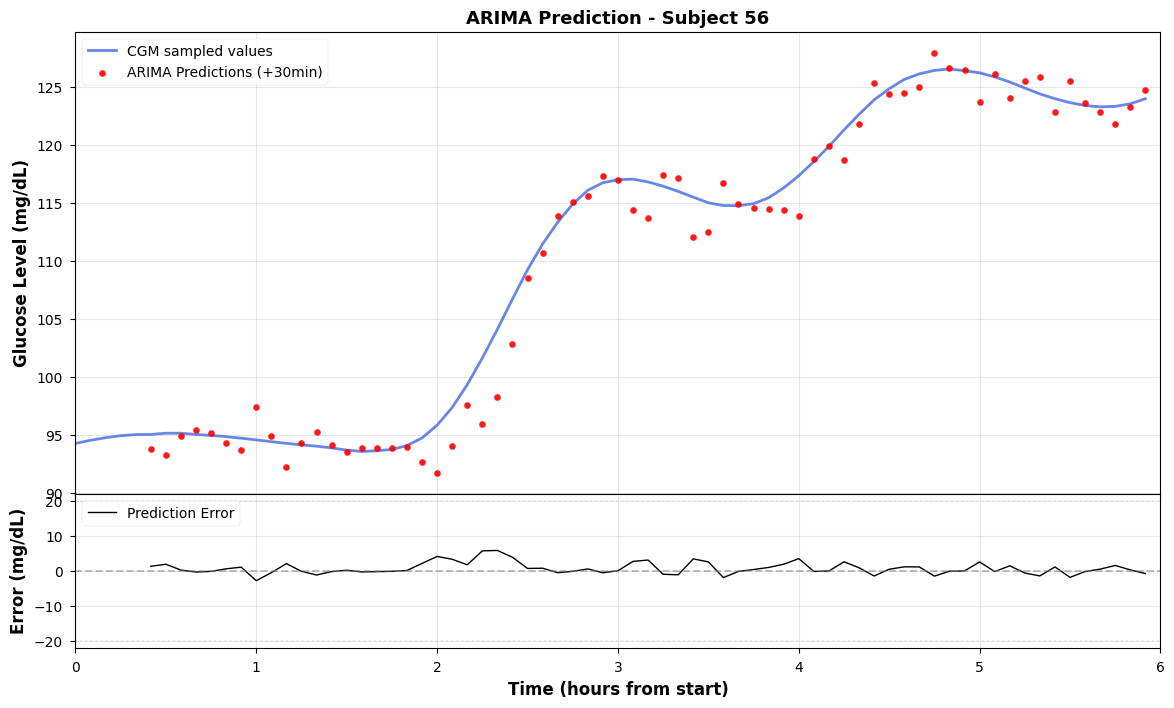

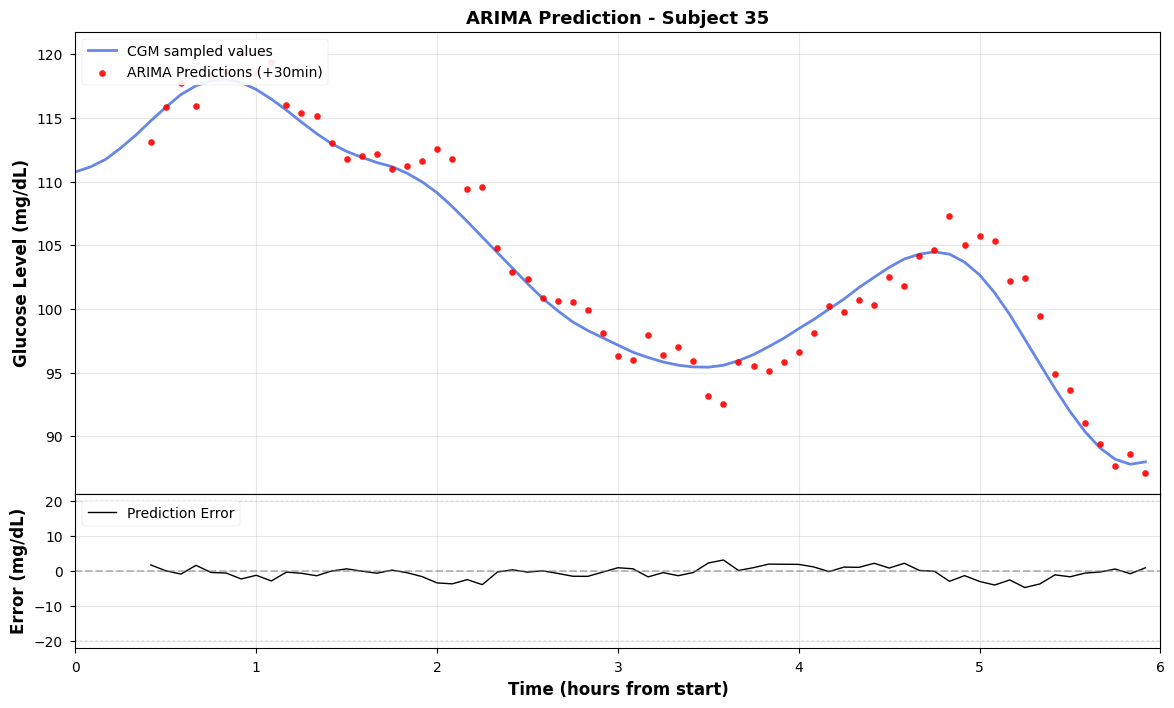

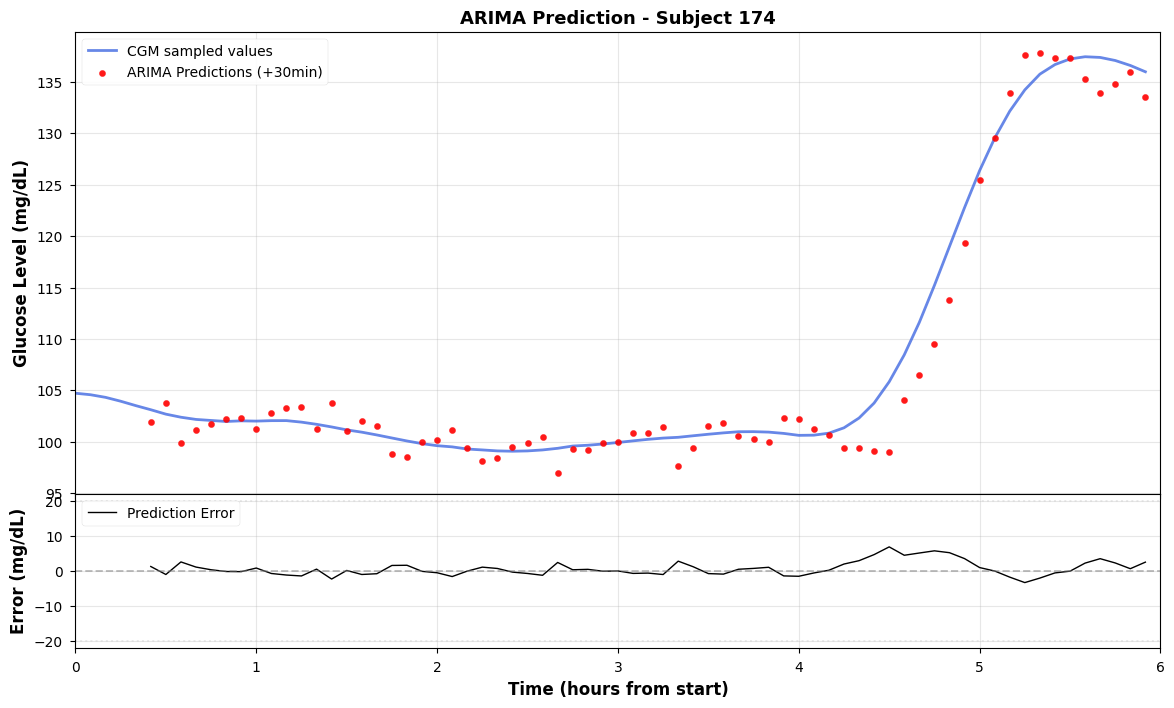

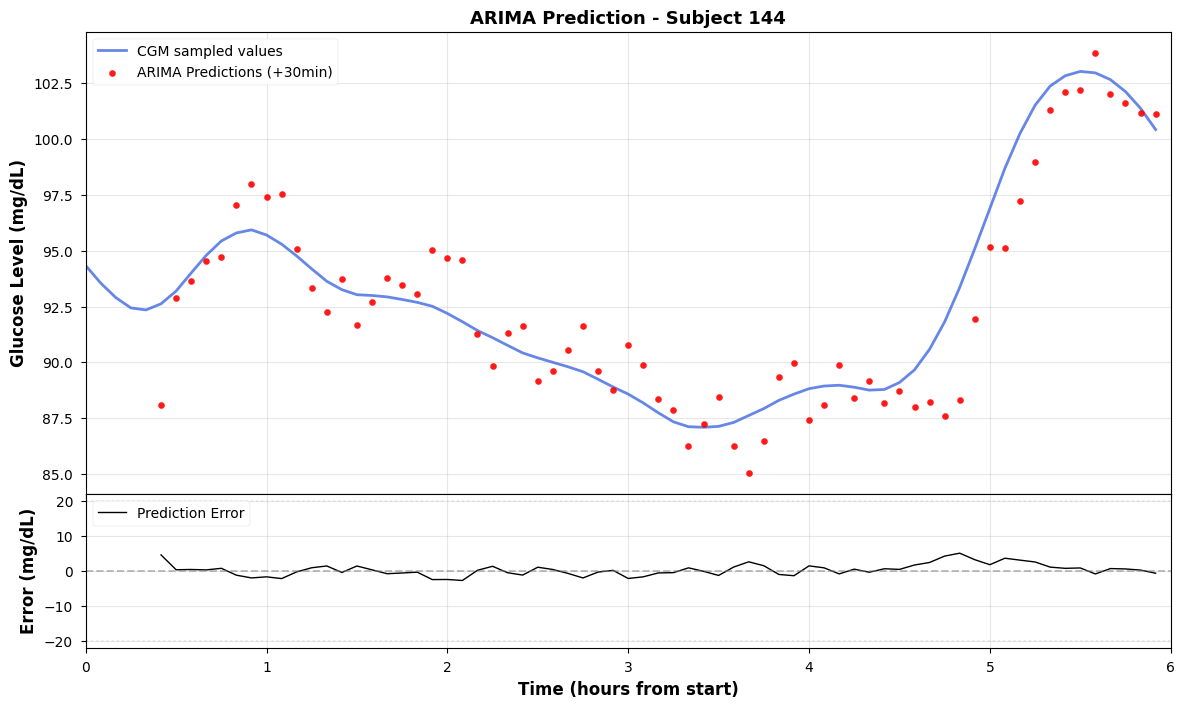

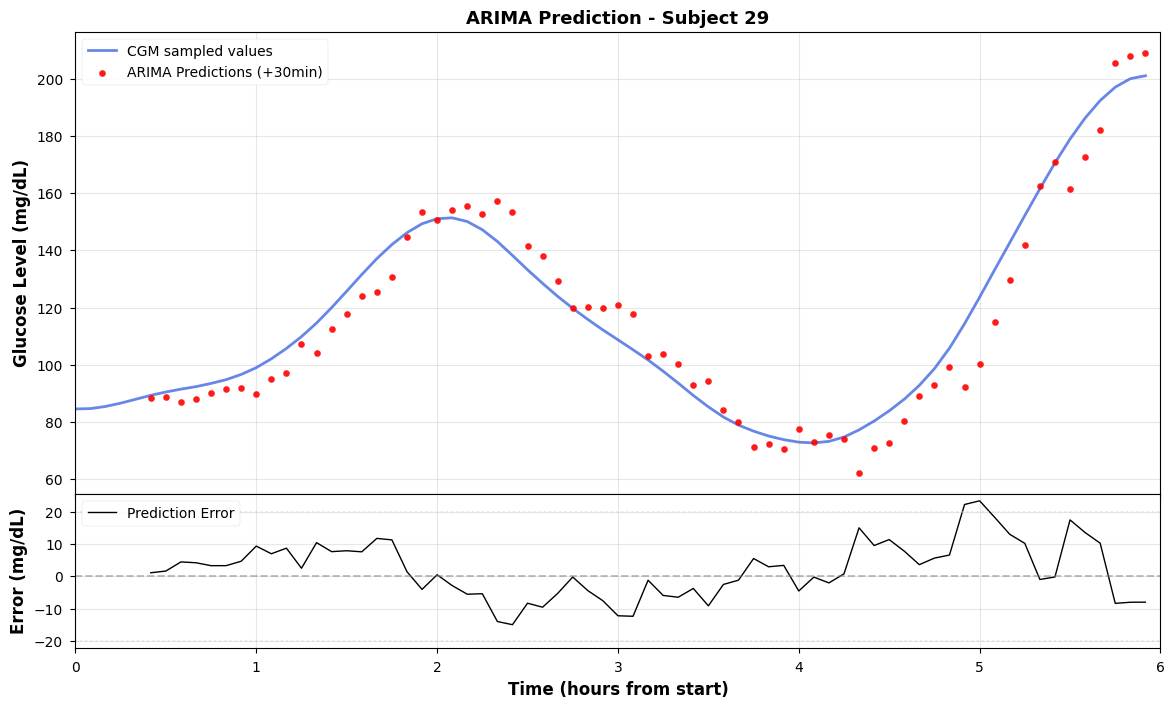

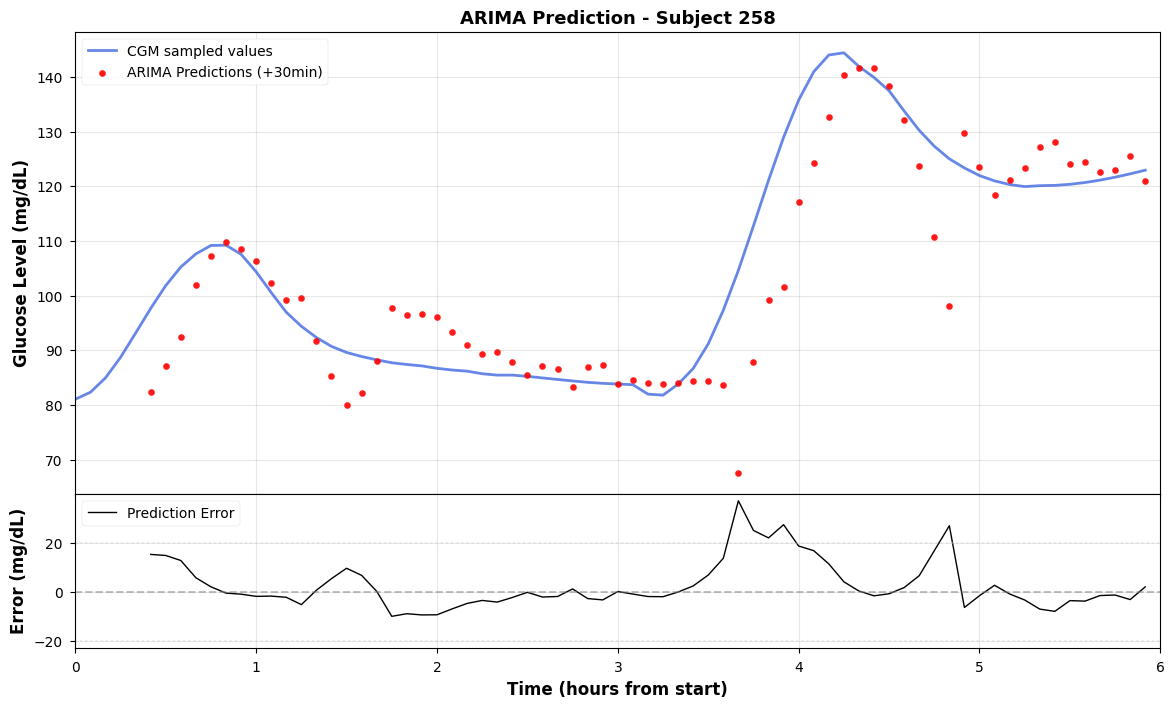

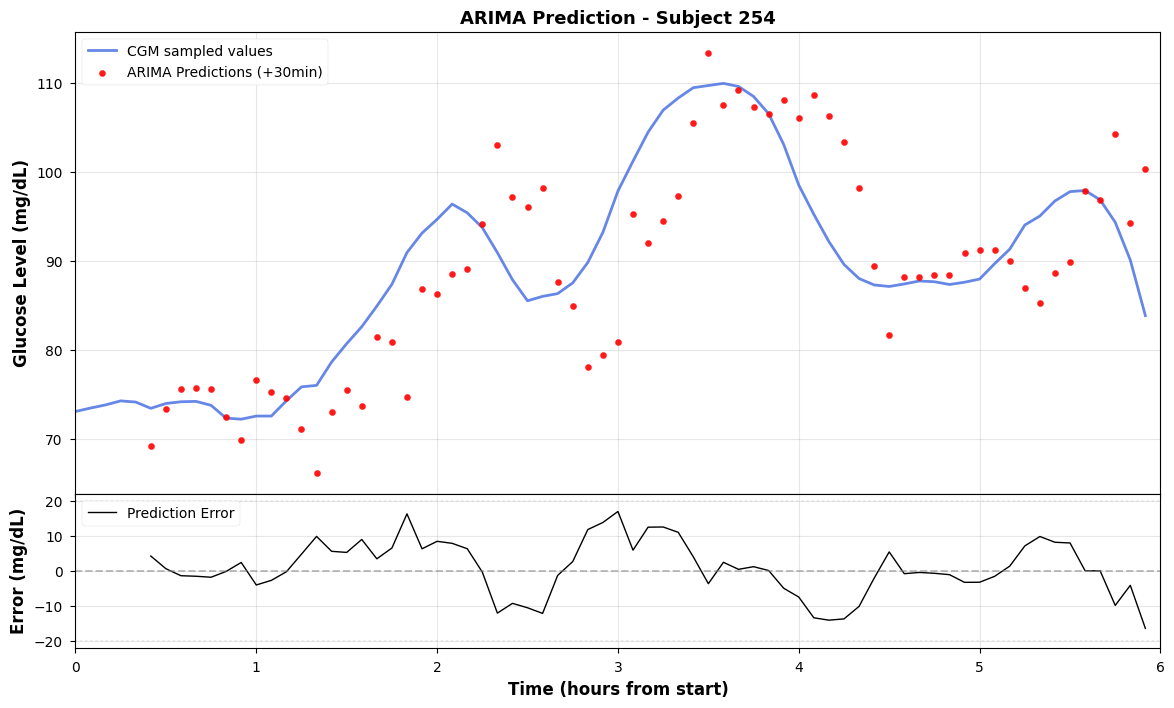

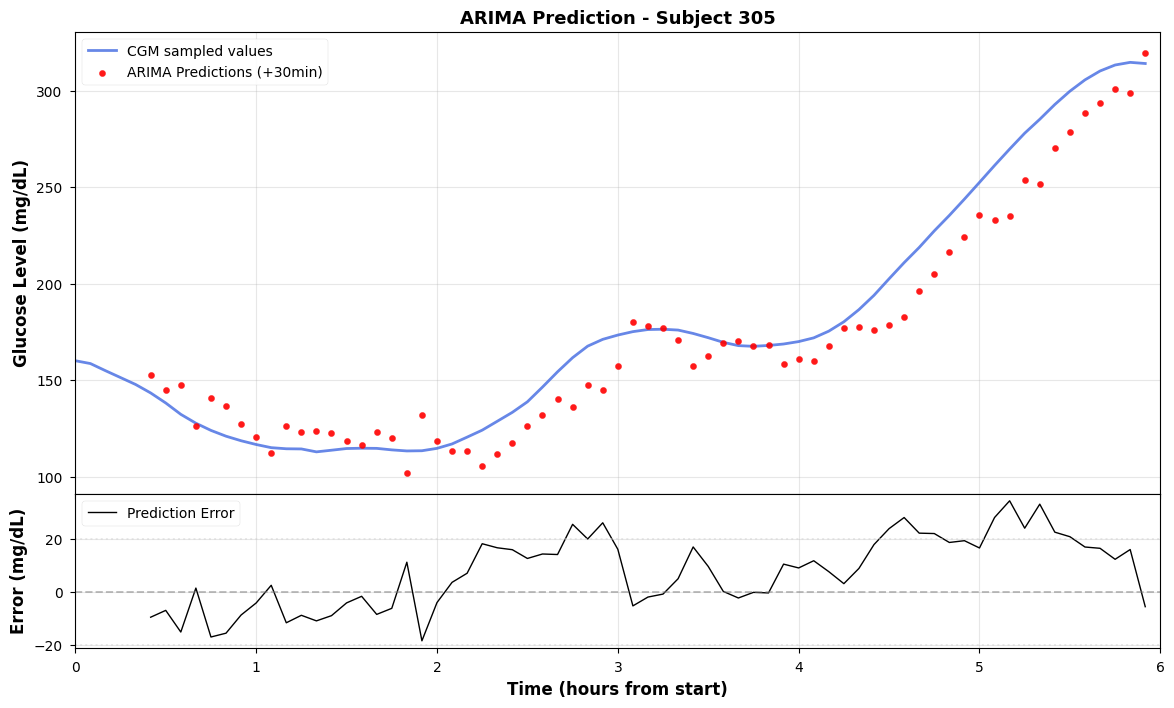

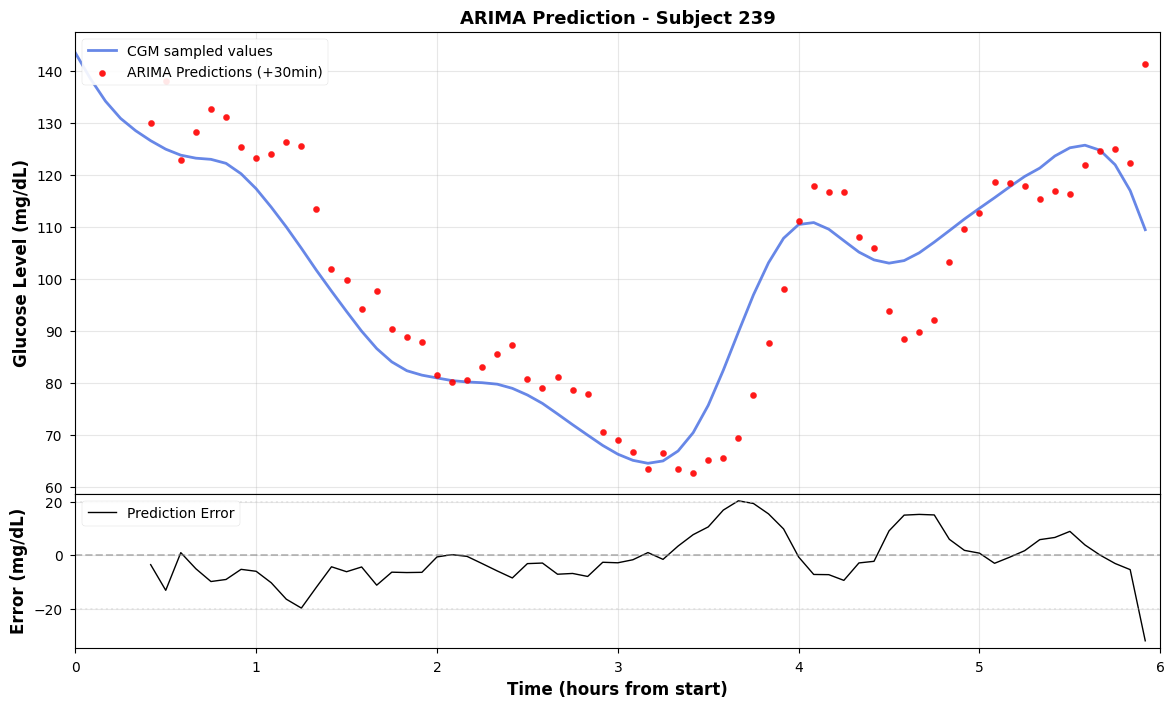

In [9]:
# 可视化：挑选最好和最差的受试者（去重）
subject_results.sort(key=lambda x: x['mape'])

n_show = min(5, len(subject_results))  # 每端最多展示5个
best_subjects = subject_results[:n_show]
worst_subjects = subject_results[-n_show:]

# 去重：如果受试者总数不足4个，best和worst会重叠
seen_ids = set()
viz_subjects = []
for s in best_subjects:
    if s['id'] not in seen_ids:
        viz_subjects.append(s)
        seen_ids.add(s['id'])
for s in worst_subjects:
    if s['id'] not in seen_ids:
        viz_subjects.append(s)
        seen_ids.add(s['id'])

print(f"可视化 {len(viz_subjects)} 个受试者 (Best {n_show} & Worst {n_show}, 去重后)...")

for stat in viz_subjects:
    subject_id = stat['id']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    subject_data = stat['data'] # 原始测试集数据
    
    # 构造时间轴 (小时)
    # 注意：y_true_subj 是从第 horizon-1 个点开始的
    # 原始数据长度
    full_len = len(subject_data)
    full_hours = np.arange(full_len) * (5 / 60)
    
    # 预测值对应的时间点
    # y_true_subj[0] 对应 subject_data 的第 PREDICTION_HORIZON - 1 个点
    start_idx = PREDICTION_HORIZON - 1
    pred_hours = full_hours[start_idx : start_idx + len(y_pred_subj)]
    
    error = y_true_subj - y_pred_subj

    # 绘图
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    # 判断排名
    rank = subject_results.index(stat) + 1
    
    # 绘制完整真实值
    ax1.plot(full_hours, subject_data['gl'].values, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    # 绘制预测点
    ax1.scatter(pred_hours, y_pred_subj, label=f'ARIMA Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'ARIMA Prediction - Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    ax2.set_xlim(0, 6)

    plt.show()

In [1]:
# --- Served Set (保留集) 预测分析 ---
# 目标：逻辑与 Linear Regression 保持完全一致
# 对每个 Served 受试者，使用滑动窗口进行全量预测 (Rolling Forecast over entire sequence)

# 1. 加载 Served 数据集
served_path = '../../DataSplit/Served/served.csv'
df_served = pd.read_csv(served_path, parse_dates=['time'])
print(f"Served 数据集加载完成，形状: {df_served.shape}")

# 2. 对每个 Served 受试者进行 ARIMA 滚动预测
# 注意：Linear Regression 是对所有满足窗口的数据进行预测。
# ARIMA 滚动预测通常非常耗时（每步都需要更新模型），为了效率我们可能需要简化，
# 但为了保持逻辑一致，我们对整个序列进行预测。

subject_ids_served = sorted(df_served['id'].unique())
all_y_true_served = []
all_y_pred_served = []
served_results = []

# 定义初始训练窗口大小 (用于第一次拟合 ARIMA)
# 这对应 Linear Regression 中的 "历史数据积累" 阶段
# Linear 直接使用 N_PAST 特征，ARIMA 需要一定长度的历史来稳定参数
INITIAL_HISTORY_LEN = 200 

print(f"开始对 {len(subject_ids_served)} 个 Served 受试者进行 ARIMA 全量滚动预测...")
print(f"注意: ARIMA 滚动预测计算量大，请耐心等待...\n")

for subject_id in subject_ids_served:
    print(f"Processing Served Subject {subject_id}...")
    
    subject_data = df_served[df_served['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    if len(gl_values) < INITIAL_HISTORY_LEN + PREDICTION_HORIZON:
        print(f"    Warning: 数据不足 (Length {len(gl_values)} < {INITIAL_HISTORY_LEN} + Horizon)，跳过。")
        continue
    
    # 分割：
    # History: 初始用于拟合的数据
    # Test: 需要预测的后续数据序列
    # 我们将从第 INITIAL_HISTORY_LEN 个点开始，逐个预测后续点
    history_series = gl_values[:INITIAL_HISTORY_LEN]
    test_series = gl_values[INITIAL_HISTORY_LEN:]
    
    # 执行滚动预测
    # 这将返回 test_series 中每个点的预测值 (根据其对应的历史)
    # preds[0] 是基于 history_series 预测 test_series[0+horizon-1] 的值 (假设 arima_rolling_forecast 逻辑)
    # 让我们回顾 arima_rolling_forecast 的定义：
    # 它对 test_series 遍历。
    # 比如 test[0] 是我们要"经过"的点。
    # 如果 arima_rolling_forecast 实现是: 预测未来 -> 观测真实值 -> 更新历史
    # 那么 preds[0] 就是站在 history_series 末尾预测的未来值。
    
    # 我们的 arima_rolling_forecast 函数实现：
    # for t in range(n_test):
    #    fit(history)
    #    forecast(horizon) -> yhat (第 horizon 步)
    #    history.append(test[t])
    
    # 意味着:
    # t=0: 使用 INITIAL_HISTORY，预测未来 horizon 步。yhat 是 test[horizon-1] 的估计。
    # 真实值对应 test_series[horizon-1]
    
    preds = arima_rolling_forecast(history_series, test_series, ARIMA_ORDER, PREDICTION_HORIZON)
    
    # 对齐真实值和预测值
    # 预测值 preds 的长度等于 test_series 的长度
    # preds[t] 对应的是 test_series[t + horizon - 1] 的预测值
    
    # 有效的真实值索引范围：[horizon-1, len(test_series)-1]
    # 对应的预测值索引范围：[0, len(test_series) - horizon]
    
    valid_len = len(test_series) - (PREDICTION_HORIZON - 1)
    
    if valid_len > 0:
        # 截取有效的预测值 (去除了末尾无法验证的部分，或者说循环只产生到这里的有效预测)
        # 等等，arima_rolling_forecast 生成了 len(test_series) 个预测
        # 第 last 个预测是基于 test_series[:-1] 预测 test_series[-1 + horizon]
        # 这个目标值超出了 test_series 的范围。
        # 所以我们只能验证那些目标值在 test_series 内的预测。
        
        y_pred_subj = np.array(preds[:valid_len])
        y_true_subj = test_series[PREDICTION_HORIZON - 1 : PREDICTION_HORIZON - 1 + valid_len]
        
        all_y_true_served.extend(y_true_subj)
        all_y_pred_served.extend(y_pred_subj)
        
        # 计算该受试者的 MAPE
        mask = y_true_subj != 0
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
        
        # 构造对应的时间轴
        # 原始数据时间
        full_time_axis = subject_data['time'].values
        # 预测值对应的时间点 (从 INITIAL_HISTORY_LEN + HORIZON - 1 开始)
        # 索引相对于 gl_values
        start_idx = INITIAL_HISTORY_LEN + PREDICTION_HORIZON - 1
        end_idx = start_idx + valid_len
        pred_times = full_time_axis[start_idx : end_idx]
        
        served_results.append({
            'id': subject_id,
            'y_true': y_true_subj,
            'y_pred': y_pred_subj,
            'mape': mape_subj,
            'data': subject_data,
            'pred_times': pred_times, # 存储预测对应的时间戳
            'start_idx': start_idx # 存储相对于原始数据的起始索引
        })
    else:
        print(f"    Warning: Test series too short for horizon {PREDICTION_HORIZON}")

# 3. 计算整体评估指标
all_y_true_served = np.array(all_y_true_served)
all_y_pred_served = np.array(all_y_pred_served)

mae_s, rmse_s, mape_s, rmspe_s = calculate_metrics(all_y_true_served, all_y_pred_served)
print("\n" + "=" * 60)
print(f"📊 Served Set ARIMA 全量评估结果 (Horizon={PREDICTION_HORIZON}, {PREDICTION_HORIZON*5} mins)")
print("=" * 60)
print(f"MAE:   {mae_s:.4f} mg/dL")
print(f"RMSE:  {rmse_s:.4f} mg/dL")
print(f"MAPE:  {mape_s:.4f}%")
print(f"RMSPE: {rmspe_s:.4f}%")
print("=" * 60)

# 4. 可视化每个 Served 受试者 (全量时间轴)
import matplotlib.dates as mdates

for stat in served_results:
    subject_id = stat['id']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    subject_data = stat['data']
    start_idx = stat['start_idx']
    
    # 构造相对时间轴 (Hours)
    full_len = len(subject_data)
    full_hours = np.arange(full_len) * (5 / 60)
    
    # 预测值对应的时间点 (Hours)
    # y_pred_subj 对应 orig data 的 [start_idx, start_idx + len]
    pred_hours = full_hours[start_idx : start_idx + len(y_pred_subj)]
    
    # 真实值 (对齐后)
    # y_true_subj 实际上就是 subject_data['gl'].values[start_idx : start_idx + len]
    
    error = y_true_subj - y_pred_subj
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    # 绘制完整真实值
    ax1.plot(full_hours, subject_data['gl'].values, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    # 绘制预测点
    ax1.scatter(pred_hours, y_pred_subj, label=f'ARIMA Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=15, alpha=0.9, zorder=5)
    
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'ARIMA Prediction - Served Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    # 误差图
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    # 设置 x 轴刻度，避免太密集
    max_hours = np.ceil(full_hours[-1])
    ax2.set_xlim(0, max_hours)
    
    # 动态调整刻度间隔
    tick_interval = max(1, int(max_hours / 15)) 
    ax2.xaxis.set_major_locator(plt.MultipleLocator(tick_interval))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    
    plt.show()
    print(f"Served Subject {subject_id}: Visualization generated.")


NameError: name 'pd' is not defined

正在绘制标准 Clarke Error Grid (使用 utils/ceg_utils.py)...


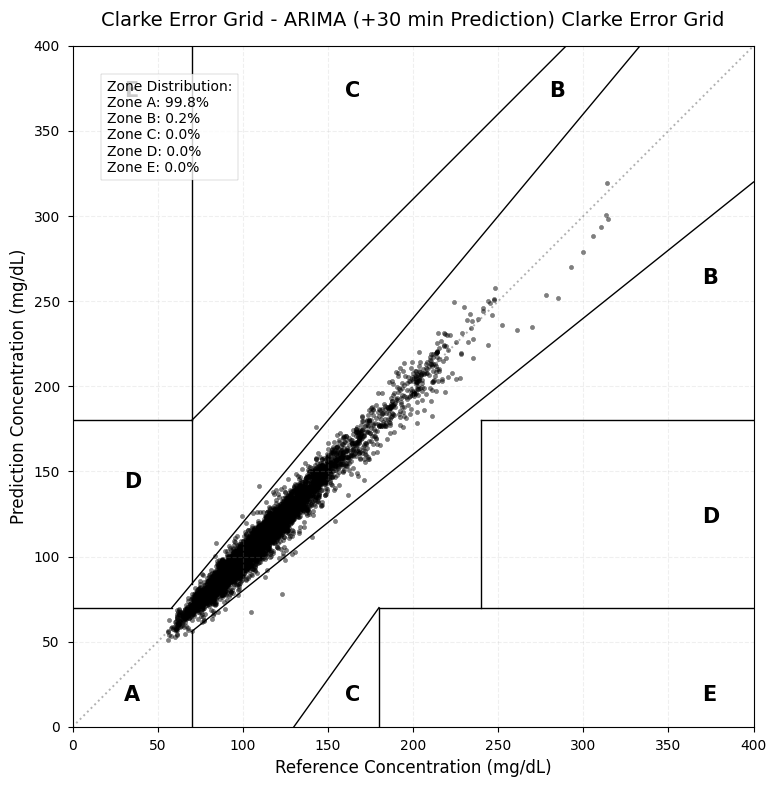


各区临床统计:
  Zone A: 99.85%
  Zone B: 0.15%
  Zone C: 0.00%
  Zone D: 0.00%
  Zone E: 0.00%
  A + B (临床安全): 100.00%


In [ ]:
import sys
import os
import importlib

# 添加 utils 目录到系统路径
# 假设当前工作目录是 notebook 所在目录 (src/Prediction/ARIMA)
# utils 目录在 ../../../utils
utils_path = os.path.abspath('../../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

try:
    import ceg_utils
    importlib.reload(ceg_utils) # 确保加载最新的修改
except ImportError:
    print(f"Error: Could not import ceg_utils from {utils_path}")

# ============ 直接调用 ============
print("=" * 60)
print("正在绘制标准 Clarke Error Grid (使用 utils/ceg_utils.py)...")
print("=" * 60)

# 调用工具函数
# 注意: ceg_utils.clarke_error_grid 返回 (plt对象, 百分比列表)
plt_obj, zones_pct_list = ceg_utils.clarke_error_grid(
    all_y_true, 
    all_y_pred, 
    title_string=f"Clarke Error Grid - ARIMA (+{PREDICTION_HORIZON*5} min Prediction)"
)

plt_obj.show()

# 转换列表为字典以便打印
zones = ['A', 'B', 'C', 'D', 'E']
zones_pct = {z: p for z, p in zip(zones, zones_pct_list)}

print("\n各区临床统计:")
for zone in ['A', 'B', 'C', 'D', 'E']:
    print(f"  Zone {zone}: {zones_pct[zone]:.2f}%")
print(f"  A + B (临床安全): {zones_pct['A'] + zones_pct['B']:.2f}%")